In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [2]:
# 1. Loading the dataset
print("Loading data...")
#[cite: 1] - Loading the dataset to a Pandas DataFrame
credit_card_data = pd.read_csv("/content/creditcard.csv")

Loading data...


In [3]:
# 2. Advanced Feature Engineering
print("Converting Time to Transaction_Hour...")
# Time is in seconds, converting it to a 24-hour cycle to catch night-time fraud patterns
credit_card_data['Transaction_Hour'] = (credit_card_data['Time'] / 3600) % 24

# 3. Data Scaling
print("Scaling features...")
scaler = StandardScaler()
credit_card_data['Amount_Scaled'] = scaler.fit_transform(credit_card_data[['Amount']])
credit_card_data['Hour_Scaled'] = scaler.fit_transform(credit_card_data[['Transaction_Hour']])

# Dropping old unscaled columns[cite: 1]
credit_card_data = credit_card_data.drop(['Time', 'Amount', 'Transaction_Hour'], axis=1)

Converting Time to Transaction_Hour...
Scaling features...


Removing extreme outliers from normal transactions...
Generating Outlier Visualization...


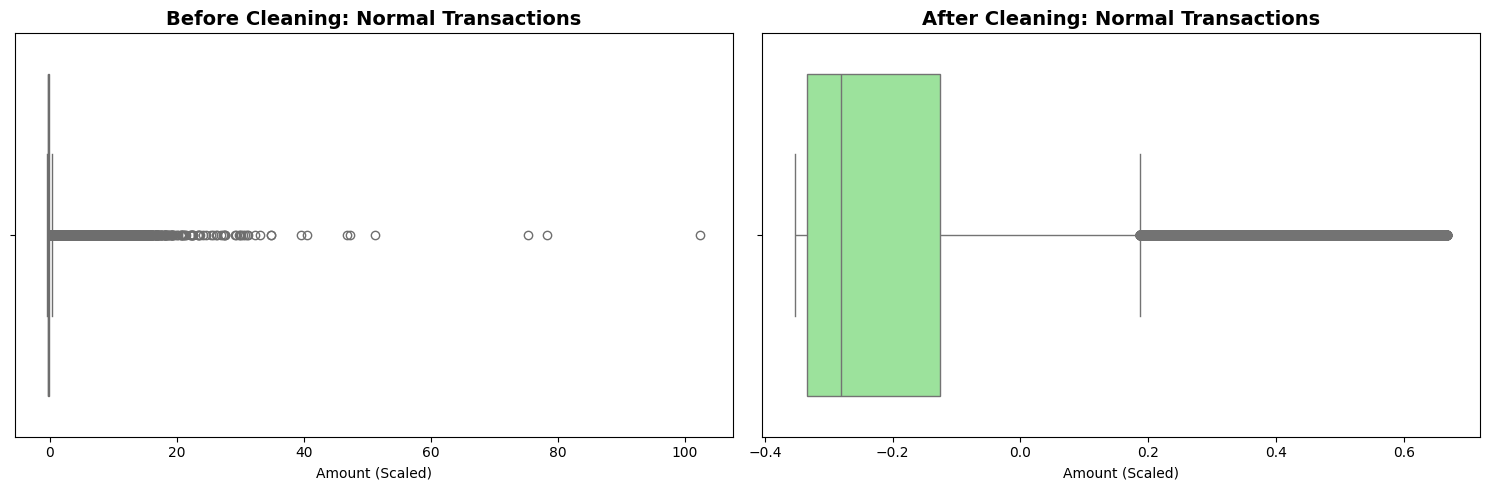


===== CHECK AFTER CELL 3 =====
Original data:
Class
0    284315
1       492
Name: count, dtype: int64

Normal clean:
Class
0    262263
Name: count, dtype: int64

Fraud:
Class
1    492
Name: count, dtype: int64

Final df_clean:
Class
0    262263
1       492
Name: count, dtype: int64
Shape: (262755, 31)


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 4. Outlier Removal Logic
print("Removing extreme outliers from normal transactions...")
Q1 = credit_card_data[credit_card_data['Class'] == 0]['Amount_Scaled'].quantile(0.25)
Q3 = credit_card_data[credit_card_data['Class'] == 0]['Amount_Scaled'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 2.5 * IQR  # 2.5 is used to be conservative
upper_bound = Q3 + 2.5 * IQR

# Defining normal_clean here so the graph can use it
normal_clean = credit_card_data[(credit_card_data['Class'] == 0) &
                                (credit_card_data['Amount_Scaled'] >= lower_bound) &
                                (credit_card_data['Amount_Scaled'] <= upper_bound)]
fraud = credit_card_data[credit_card_data['Class'] == 1]
df_clean = pd.concat([normal_clean, fraud], axis=0)

# 1. Graph Generation
print("Generating Outlier Visualization...")
plt.figure(figsize=(15, 5))

# 1st Graph: BEFORE Outlier Removal
plt.subplot(1, 2, 1)
sns.boxplot(x=credit_card_data[credit_card_data['Class'] == 0]['Amount_Scaled'], color='lightcoral')
plt.title('Before Cleaning: Normal Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Amount (Scaled)')

# 2nd Graph: AFTER Outlier Removal
plt.subplot(1, 2, 2)
sns.boxplot(x=normal_clean['Amount_Scaled'], color='lightgreen')
plt.title('After Cleaning: Normal Transactions', fontsize=14, fontweight='bold')
plt.xlabel('Amount (Scaled)')

plt.tight_layout()
plt.show()
print("\n===== CHECK AFTER CELL 3 =====")
print("Original data:")
print(credit_card_data['Class'].value_counts())

print("\nNormal clean:")
print(normal_clean['Class'].value_counts())

print("\nFraud:")
print(fraud['Class'].value_counts())

print("\nFinal df_clean:")
print(df_clean['Class'].value_counts())
print("Shape:", df_clean.shape)

In [6]:
df_clean = df_clean.dropna()

print("Class distribution AFTER CLEANING:")
print(df_clean['Class'].value_counts())

df_clean.to_csv("cleaned_data.csv", index=False)

print(f"Clean & Verified Data Saved! Shape: {df_clean.shape}")

Class distribution AFTER CLEANING:
Class
0    262263
1       492
Name: count, dtype: int64
Clean & Verified Data Saved! Shape: (262755, 31)


In [8]:
fraud_indices = credit_card_data[credit_card_data['Class'] == 1].index

print(fraud_indices[:10].tolist())

[541, 623, 4920, 6108, 6329, 6331, 6334, 6336, 6338, 6427]
